### Setup

In [ ]:
import os
import multiprocessing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset,DataLoader
from torchvision.transforms import transforms

import nibabel as nib
import albumentations as alb

In [30]:
seed = 42
device = 'cuda' if torch.cuda.is_available() else 'cpu'

### Data Paths

In [20]:
def create_dataset_path_df(dataset_dir):
    flair_suffix = "flair.nii.gz"
    t1_suffix = "t1.nii.gz"
    t1ce_suffix = "t1ce.nii.gz"
    t2_suffix = "t2.nii.gz"
    seg_suffix = "seg.nii.gz"
    dataset_dict = {
                    'directory_path':[],
                    'flair_path':[],
                    't1_path':[],
                    't1ce_path':[],
                    't2_path':[],
                    'seg_path':[]
                    }
    missing_flair = 0
    missing_t1 = 0
    missing_t1ce = 0
    missing_t2 = 0
    missing_seg = 0
    missing_files_dirs = []
    for dir in os.listdir(dataset_dir):
        dir_path = os.path.join(dataset_dir,dir)
        if not os.path.isdir(dir_path) or not dir.startswith('BraTS2021'):
            continue
        dataset_dict['directory_path'].append(dir_path)
        
        flair_found = t1_found = t1ce_found = t2_found = seg_found = False
        for image in os.listdir(dir_path):
            image_path = os.path.join(dir_path, image)

            if image.endswith(flair_suffix):
                dataset_dict['flair_path'].append(image_path)
                flair_found = True
            elif image.endswith(t1_suffix):
                dataset_dict['t1_path'].append(image_path)
                t1_found = True
            elif image.endswith(t1ce_suffix):
                dataset_dict['t1ce_path'].append(image_path)
                t1ce_found = True
            elif image.endswith(t2_suffix):
                dataset_dict['t2_path'].append(image_path)
                t2_found = True
            elif image.endswith(seg_suffix):
                dataset_dict['seg_path'].append(image_path)
                seg_found = True

        if not flair_found:
            dataset_dict['flair_path'].append(None)
            missing_flair += 1
        if not t1_found:
            dataset_dict['t1_path'].append(None)
            missing_t1 += 1
        if not t1ce_found:
            dataset_dict['t1ce_path'].append(None)
            missing_t1ce += 1
        if not t2_found:
            dataset_dict['t2_path'].append(None)
            missing_t2 += 1
        if not seg_found:
            dataset_dict['seg_path'].append(None)
            missing_seg += 1
        if flair_found or t1_found or t1ce_found or t2_found or seg_found:
            pass
        else:
            missing_files_dirs.append(dir_path)
    print(f"Total missing files:")
    print(f"  - Flair: {missing_flair}")
    print(f"  - T1: {missing_t1}")
    print(f"  - T1ce: {missing_t1ce}")
    print(f"  - T2: {missing_t2}")
    print(f"  - Seg: {missing_seg}")
    print(f"Missing files at: {missing_files_dirs}")
    return pd.DataFrame(dataset_dict)

    return dataset_dict
dataset_dir = "../data/brats2021"
dataset = create_dataset_path_df(dataset_dir)
dataset.head()

Total missing files:
  - Flair: 1
  - T1: 1
  - T1ce: 1
  - T2: 1
  - Seg: 1
Missing files at: ['../data/brats2021/BraTS2021_00539']


,directory_path,flair_path,t1_path,t1ce_path,t2_path,seg_path
0,../data/brats2021/BraTS2021_00000,../data/brats2021/BraTS2021_00000/BraTS2021_00...,../data/brats2021/BraTS2021_00000/BraTS2021_00...,../data/brats2021/BraTS2021_00000/BraTS2021_00...,../data/brats2021/BraTS2021_00000/BraTS2021_00...,../data/brats2021/BraTS2021_00000/BraTS2021_00...
1,../data/brats2021/BraTS2021_00002,../data/brats2021/BraTS2021_00002/BraTS2021_00...,../data/brats2021/BraTS2021_00002/BraTS2021_00...,../data/brats2021/BraTS2021_00002/BraTS2021_00...,../data/brats2021/BraTS2021_00002/BraTS2021_00...,../data/brats2021/BraTS2021_00002/BraTS2021_00...
2,../data/brats2021/BraTS2021_00003,../data/brats2021/BraTS2021_00003/BraTS2021_00...,../data/brats2021/BraTS2021_00003/BraTS2021_00...,../data/brats2021/BraTS2021_00003/BraTS2021_00...,../data/brats2021/BraTS2021_00003/BraTS2021_00...,../data/brats2021/BraTS2021_00003/BraTS2021_00...
3,../data/brats2021/BraTS2021_00005,../data/brats2021/BraTS2021_00005/BraTS2021_00...,../data/brats2021/BraTS2021_00005/BraTS2021_00...,../data/brats2021/BraTS2021_00005/BraTS2021_00...,../data/brats2021/BraTS2021_00005/BraTS2021_00...,../data/brats2021/BraTS2021_00005/BraTS2021_00...
4,../data/brats2021/BraTS2021_00006,../data/brats2021/BraTS2021_00006/BraTS2021_00...,../data/brats2021/BraTS2021_00006/BraTS2021_00...,../data/brats2021/BraTS2021_00006/BraTS2021_00...,../data/brats2021/BraTS2021_00006/BraTS2021_00...,../data/brats2021/BraTS2021_00006/BraTS2021_00...


In [23]:
train_size = 0.8
val_size = 0.1
test_size = 0.1
random_state = 42
dataset_train, temp = train_test_split(dataset, test_size = val_size+test_size, random_state = random_state)
dataset_val, dataset_test = train_test_split(temp, test_size = test_size / (val_size + test_size), random_state = random_state)
print(f"Train set shape: {dataset_train.shape}")
print(f"Validation set shape: {dataset_val.shape}")
print(f"Test set shape: {dataset_test.shape}")

Train set shape: (300, 6)
Validation set shape: (38, 6)
Test set shape: (38, 6)


### Custom Dataset Class

In [70]:
class BrainTumorDataset(Dataset):
    def __init__(self, datapath_df, upper_bound=100, lower_bound=60, window_size = 3, transforms=None):
        self._datapath_df = datapath_df
        self.upper_bound = upper_bound
        self.lower_bound = lower_bound
        self.window_size = window_size
        self.transforms = transforms

    def __len__(self):
        return self._datapath_df.shape[0]

    def _get_adjacent_slices(self, data, mask):
        # Return data: [Height x Width x (Modalities*window_size), ] * (Depth-window_size+1), 
        # Return mask: [Height x Width] * (Depth-window_size+1)
        data = [data[:,:,:,i].transpose(1,2,0) for i in range(max(self.lower_bound,0), min(self.upper_bound,data.shape[-1]))]
        mask = [mask[:,:,i] for i in range(max(self.lower_bound,0), min(self.upper_bound,mask.shape[-1]))]
        return data, mask

    def __getitem__(self, index):
        data = []
        row = self._datapath_df.iloc[index]
        data.append(nib.load(row.flair_path).get_fdata())
        data.append(nib.load(row.t1_path).get_fdata())
        data.append(nib.load(row.t1ce_path).get_fdata())
        data.append(nib.load(row.t2_path).get_fdata())
        data = np.stack(data, axis=0)
        mask = nib.load(row.seg_path).get_fdata()

        data, mask = self._get_adjacent_slices(data, mask) 
        if self.transforms:
            spatial_transforms = self.transforms.get('spatial_transforms',None)
            intensity_transforms = self.transforms.get('intensity_transforms',None)
            
            if spatial_transforms:
                for i in range(len(data)):
                    augmented_data = spatial_transforms(image=data[i], mask=mask[i])
                    data[i], mask[i] = augmented_data["image"], augmented_data["mask"]
            if spatial_transforms:
                for i in range(len(data)):
                    augmented_data = spatial_transforms(image=data[i])
                    data[i] = augmented_data["image"]
            
        return data, mask

### Transforms

| **Augmentation**    | **Function**                                                                                             | **Reasoning**                                                                                                                                       |
|-------------------------------|-------------------------------------------------------------------------------------------------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Horizontal Flip               | Randomly flips the image horizontally.                                                                                 | Increases training data diversity; however, caution is needed because brain hemispheres can be lateralized, and tumors may show a side-specific distribution.    |
| Rotation                      | Rotates the image by a small angle (±5°).                                                                               | Mimics slight head tilts during MRI acquisition, helping the model learn minor orientation variations without distorting anatomical structures.                  |
| Random Scale                  | Scales the image by a factor within ±8%.                                                                               | Simulates variations in scanner zoom or patient size while preserving the relative sizes of brain structures and tumor-to-brain ratios.                             |
| Elastic Transform             | Applies smooth, local deformations to the image.                                                                       | Mimics realistic soft-tissue deformations in MR images; careful parameter tuning prevents unrealistic warping of critical tumor morphology.                       |
| Affine Transform              | Performs minor translations, rotations, and scaling simultaneously.                                                  | Adjusts for slight differences in patient positioning; maintains anatomical consistency while introducing subtle spatial variability.                           |
| Pad & Resize                  | Pads the image (if necessary) and resizes it to a fixed dimension (e.g., 240×240).                                      | Ensures uniform input dimensions for the network, which is vital for consistent performance and accurate segmentation.                                             |
| Random Brightness/Contrast    | Adjusts brightness and contrast within a moderate range (±15%).                                                        | Reflects variations in imaging conditions and scanner calibration while preserving subtle tumor intensity differences critical for segmentation.                |
| GaussNoise                    | Adds Gaussian noise with moderate variance.                                                                          | Emulates scanner noise found in real MR images, which helps the model become robust to noise without masking important details of tumor boundaries.             |
| Random Gamma Correction       | Modifies the image gamma within a narrow range (98–102).                                                               | Maintains clinically relevant intensity distributions and preserves tumor contrast, ensuring that subtle intensity variations remain interpretable.              |
| Median Blur                   | Applies a slight blur to reduce noise while preserving edges.                                                        | Helps in reducing high-frequency noise and artifacts without losing the sharp boundaries needed for precise delineation of tumor margins.                         |


In [71]:
transforms = {}
spatial_transforms = alb.Compose([
    alb.HorizontalFlip(p=0.3),
    alb.Rotate(limit=5, p=0.3),
    alb.RandomScale(scale_limit=0.08, p=0.3),
    alb.ElasticTransform(alpha=1, sigma=2.5, p=0.2),
    alb.Affine(scale=(0.95, 1.05), translate_percent=(0.02, 0.02), rotate=(-5, 5), p=0.3, fit_output=False),
    alb.PadIfNeeded(min_height=240, min_width=240),
    alb.Resize(240, 240)
], additional_targets={"mask":"mask"})
intensity_transforms = alb.Compose([
    alb.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.4),
    alb.GaussNoise(p=0.3),
    alb.RandomGamma(gamma_limit=(98,102), p=0.3),
    alb.MedianBlur(blur_limit=3, p=0.2),
])
transforms['spatial_transforms'] = spatial_transforms
transforms['intensity_transforms'] = intensity_transforms

In [72]:
upper_bound=100
lower_bound=60 
window_size = 3
test_data = BrainTumorDataset(dataset_test,
                             upper_bound=upper_bound, 
                             lower_bound=lower_bound, 
                             window_size = window_size, 
                             transforms=transforms)
data, mask = test_data[0]
print(f"Number of Datapoits: {len(data)}")
print(f"Data Shape: {data[0].shape}")
print(f"Mask Shape: {mask[0].shape}")

Number of Datapoits: 40
Data Shape: (240, 240, 4)
Mask Shape: (240, 240)


Text(0.5, 1.0, 'Mask')

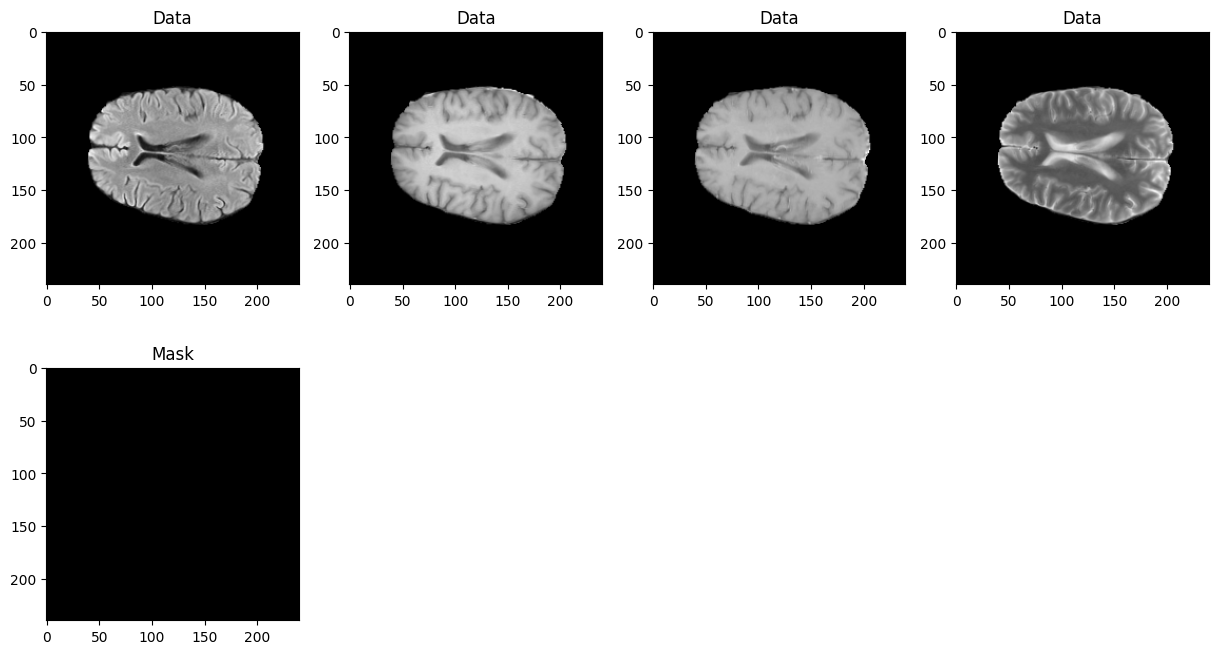

In [65]:
idx = np.random.randint(upper_bound-lower_bound)

plt.figure(figsize=(15,8))

for i in range(data[idx].shape[-1]):
    plt.subplot(2,4,i+1)
    plt.imshow(data[idx][:,:,i], cmap="gray")
    plt.title("Data")

plt.subplot(2,4,i+2)
plt.imshow(mask[idx], cmap="nipy_spectral")
plt.title("Mask")

### Dataloader

In [73]:
upper_bound=100
lower_bound=60 
window_size = 3
train_data = BrainTumorDataset(dataset_train,
                             upper_bound=upper_bound, 
                             lower_bound=lower_bound, 
                             window_size = window_size, 
                             transforms=transforms)
val_data = BrainTumorDataset(dataset_val,
                             upper_bound=upper_bound, 
                             lower_bound=lower_bound, 
                             window_size = window_size, 
                             transforms=transforms)
test_data = BrainTumorDataset(dataset_test,
                             upper_bound=upper_bound, 
                             lower_bound=lower_bound, 
                             window_size = window_size, 
                             transforms=transforms)
pd.Series({
    'Training dataset size:': len(train_data),
    'Validation dataset size:': len(val_data),
    'Testing dataset size:': len(test_data)
}).to_frame().style.hide(axis='columns')

Training dataset size:,300
Validation dataset size:,38
Testing dataset size:,38


In [74]:
def collate_fn(batch):
    data = []
    mask = []
    for X, label in batch:
        data.extend(X)
        mask.extend(label)
    data = np.array(data)
    mask = np.array(mask)
    data = torch.tensor(data, dtype=torch.float32)
    mask = torch.tensor(mask, dtype=torch.float32)
    return data, mask

per_datapoint_batch_size = (upper_bound-lower_bound)-window_size+1
batch_size_multiplication_factor = 2
batch_size = int(per_datapoint_batch_size*batch_size_multiplication_factor)
num_workers = multiprocessing.cpu_count()//2
num_workders = 2
persistent_workers = True
pin_memory = True if device=='cuda' else False
pin_memory_device = device
data_loader_params = {
    'batch_size': batch_size_multiplication_factor,
    'num_workers': num_workers,
    'persistent_workers': persistent_workers,
    'pin_memory': pin_memory,
    'pin_memory_device': pin_memory_device,
    'collate_fn': collate_fn,
}
print(f'Number of datapoints per batch {batch_size}')
train_dataloader = DataLoader(train_data, **data_loader_params, shuffle=True)
val_dataloader = DataLoader(val_data, **data_loader_params)
test_dataloader = DataLoader(test_data, **data_loader_params)

Number of datapoints per batch 76


In [75]:
pd.Series({
    'Number of batches in train dataLoader:': len(train_dataloader),
    'Number of batches in validation dataLoader:': len(val_dataloader),
    'Number of batches in test dataLoader:': len(test_dataloader)
}).to_frame().style.hide(axis='columns')

Number of batches in train dataLoader:,150
Number of batches in validation dataLoader:,19
Number of batches in test dataLoader:,19


In [76]:
for batch_idx, (data, mask) in enumerate(train_dataloader):
    print(f"Batch {batch_idx}:")
    print(f"  Data shape: {data.shape}")
    print(f"  Mask shape: {mask.shape}")
    break

Batch 0:
  Data shape: torch.Size([80, 240, 240, 4])
  Mask shape: torch.Size([80, 240, 240])
